In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
import umap


In [2]:
def load_manifesto(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

def chunk_text(text, chunk_size=300):
    import re
    sentences = re.split(r'[.!?]\s+', text)
    chunks = []
    current_chunk = ""
    for sent in sentences:
        if len(current_chunk.split()) + len(sent.split()) < chunk_size:
            current_chunk += " " + sent
        else:
            chunks.append(current_chunk.strip())
            current_chunk = sent
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

In [3]:
# Option 1: MiniLM
#model_name = 'all-MiniLM-L6-v2'
# Option 2: MPNet (better, slower)
model_name = 'all-mpnet-base-v2'

model = SentenceTransformer(model_name)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
data_dir = "masked_pdf_data"
manifestos = {}
embeddings = {}
labels = []

for party in ["BJP", "INC"]:
    for year in ["2009", "2014", "2019"]:
        file_path = os.path.join(data_dir, f"{party}_{year}.txt")
        print(f"Loading {file_path}")
        text = load_manifesto(file_path)
        chunks = chunk_text(text)
        print(f"{len(chunks)} chunks")

        embs = model.encode(chunks, batch_size=32, show_progress_bar=True)

        key = f"{party}_{year}"
        manifestos[key] = chunks
        embeddings[key] = embs
        labels.extend([key] * len(embs))

# Combine all embeddings
all_embeddings = np.vstack([emb for emb_list in embeddings.values() for emb in emb_list])
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_2d = umap_model.fit_transform(all_embeddings)
all_labels = np.array(labels)

Loading masked_pdf_data/BJP_2009.txt
58 chunks


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Loading masked_pdf_data/BJP_2014.txt
69 chunks


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Loading masked_pdf_data/BJP_2019.txt
64 chunks


...

Loading masked_pdf_data/INC_2014.txt
60 chunks


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Loading masked_pdf_data/INC_2019.txt
82 chunks


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/hduhan/324_final_project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


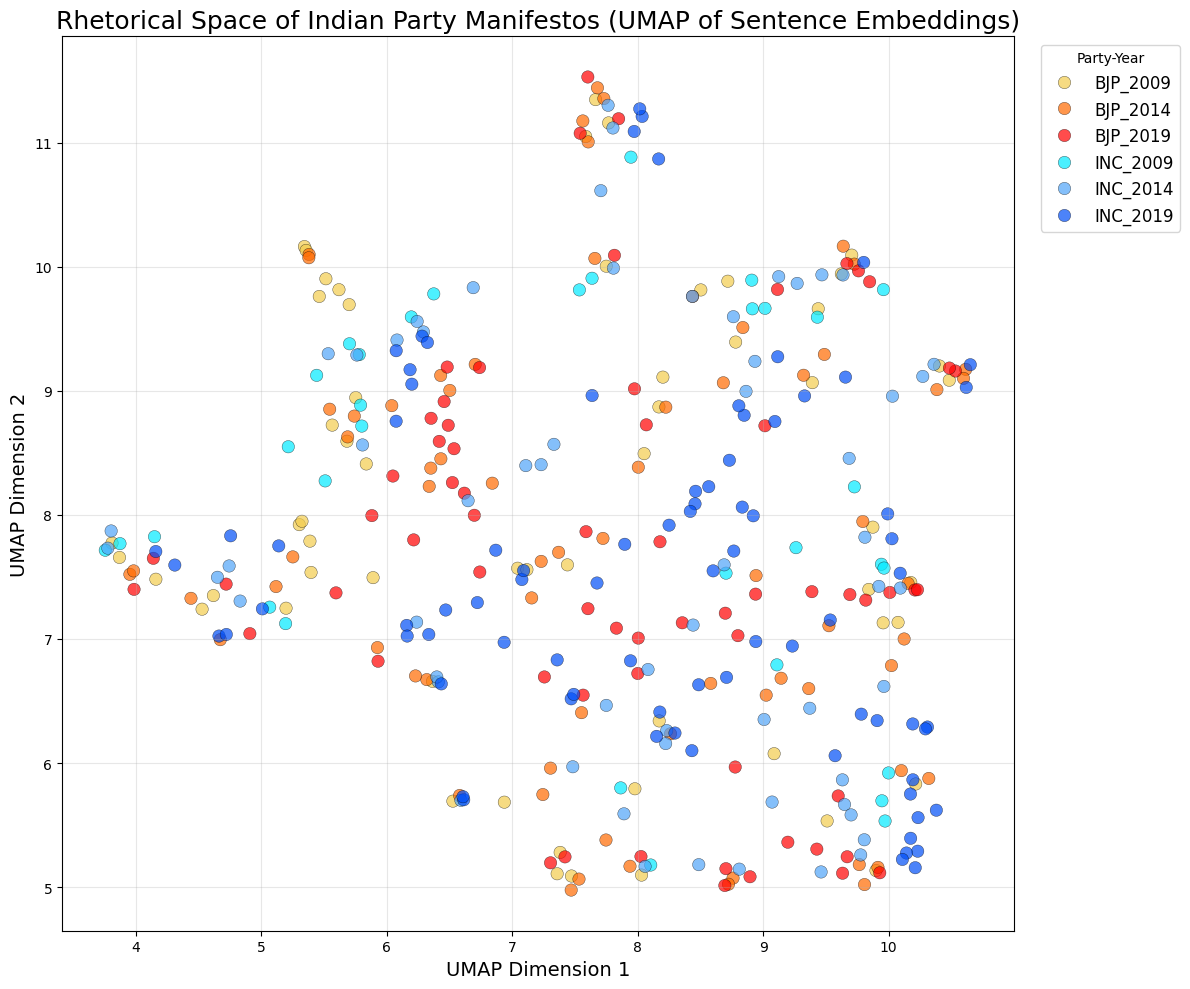

In [14]:
# UMAP with fixed color palette

# Define custom palette
custom_palette = {
    'BJP_2009': "#F3CC4D",  # orange
    'BJP_2014': "#FF6A00",  # dark orange
    'BJP_2019': "#FF0000",  # reddish orange
    'INC_2009': "#00EAFF",  # steel blue
    'INC_2014': "#50A4F9",  # dodger blue
    'INC_2019': "#004EF7"   # deep sky blue
}

# Plot UMAP
plt.figure(figsize=(12,10))
sns.scatterplot(
    x=embeddings_2d[:,0], y=embeddings_2d[:,1], 
    hue=all_labels, palette=custom_palette, 
    s=80, alpha=0.7, edgecolor='black', linewidth=0.3
)

plt.title("Rhetorical Space of Indian Party Manifestos (UMAP of Sentence Embeddings)", fontsize=18)
plt.xlabel("UMAP Dimension 1", fontsize=14)
plt.ylabel("UMAP Dimension 2", fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title="Party-Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("1MPNet_umap_scatter_custom.png", dpi=400)
plt.show()


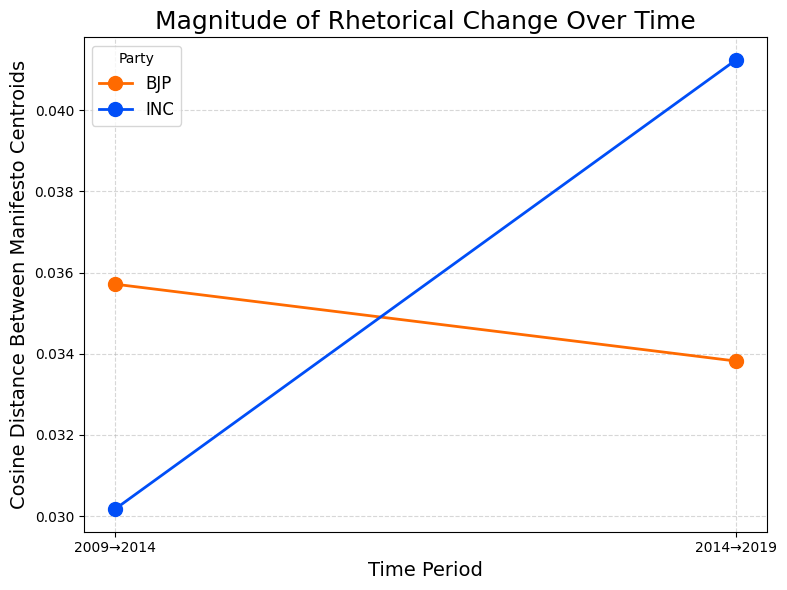


=== Rhetorical Drift (Cosine Distance) ===
BJP:
  2009→2014: 0.0357
  2014→2019: 0.0338
INC:
  2009→2014: 0.0302
  2014→2019: 0.0412

=== Total Rhetorical Drift (2009→2019) ===
BJP: 0.0695
INC: 0.0714

=== BJP drift exceeds INC by -0.0019 (-2.6%) ===


In [15]:
# Compute centroids in original embedding space
centroids = {}
for key, embs in embeddings.items():
    centroids[key] = np.mean(embs, axis=0)

# Compute drift distances
time_distances = {"BJP": [], "INC": []}

for party in ["BJP", "INC"]:
    years = ["2009", "2014", "2019"]
    for i in range(len(years)-1):
        k1 = f"{party}_{years[i]}"
        k2 = f"{party}_{years[i+1]}"
        d = cosine_distances([centroids[k1]], [centroids[k2]])[0][0]
        time_distances[party].append(d)

# Plot drift (BJP orange, INC blue)
party_line_colors = {"BJP": "#FF6A00", "INC": "#004EF7"}
plt.figure(figsize=(8,6))
for party in ["BJP", "INC"]:
    plt.plot(
        ["2009→2014", "2014→2019"],
        time_distances[party],
        marker="o",
        markersize=10,
        linewidth=2,
        label=party,
        color=party_line_colors[party],
    )

plt.xlabel("Time Period", fontsize=14)
plt.ylabel("Cosine Distance Between Manifesto Centroids", fontsize=14)
plt.title("Magnitude of Rhetorical Change Over Time", fontsize=18)
plt.legend(fontsize=12, title="Party")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("1MPNet_rhetorical_drift_corrected.png", dpi=400)
plt.show()
# === Print actual delta values ===

print("\n=== Rhetorical Drift (Cosine Distance) ===")
for party in ["BJP", "INC"]:
    print(f"{party}:")
    for i, dist in enumerate(time_distances[party]):
        print(f"  {['2009→2014', '2014→2019'][i]}: {dist:.4f}")

# === Compare party total drift ===

total_drift = {}
for party in ["BJP", "INC"]:
    total_drift[party] = sum(time_distances[party])

print("\n=== Total Rhetorical Drift (2009→2019) ===")
for party in ["BJP", "INC"]:
    print(f"{party}: {total_drift[party]:.4f}")

# === Difference between parties ===

diff = total_drift["BJP"] - total_drift["INC"]
percent = (diff / total_drift["INC"]) * 100

print(f"\n=== BJP drift exceeds INC by {diff:.4f} ({percent:.1f}%) ===")



In [16]:
# Prepare features and labels
X_bert = all_embeddings
y_party = np.array([label.split('_')[0] for label in all_labels])

# Logistic regression classifier
clf_bert = LogisticRegression(max_iter=1000)
scores_bert = cross_val_score(clf_bert, X_bert, y_party, cv=5, scoring='accuracy')
f1_bert = cross_val_score(clf_bert, X_bert, y_party, cv=5, scoring='f1_macro')

print("=== Party Prediction: BERT Embeddings ===")
print(f"Accuracy: {scores_bert.mean():.4f}, F1: {f1_bert.mean():.4f}")

=== Party Prediction: BERT Embeddings ===
Accuracy: 0.7593, F1: 0.7569


In [17]:
# Reconstruct paragraphs
paragraphs = [para for chunk_list in manifestos.values() for para in chunk_list]

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(paragraphs).toarray()

# Logistic regression classifier
clf_tfidf = LogisticRegression(max_iter=1000)
scores_tfidf = cross_val_score(clf_tfidf, X_tfidf, y_party, cv=5, scoring='accuracy')
f1_tfidf = cross_val_score(clf_tfidf, X_tfidf, y_party, cv=5, scoring='f1_macro')

print("=== Party Prediction: TF-IDF Baseline ===")
print(f"Accuracy: {scores_tfidf.mean():.4f}, F1: {f1_tfidf.mean():.4f}")

=== Party Prediction: TF-IDF Baseline ===
Accuracy: 0.9098, F1: 0.9080


In [18]:
clf_bert = LogisticRegression(max_iter=1000).fit(X_bert, y_party)

In [19]:
test_paragraph = "For the first time, India has started marching and is being seen on the path of global standards in infrastructure and civic amenities. The speed of constructing rural roads has doubled and 90% of rural road connectivity has been achieved. Furthermore, India has become a net exporter of electricity and has achieved maximum production of coal and maximum distribution of LED bulbs. There has been an unprecedented rise in the port capacity and the speed of settinging up new rail lines, gauge conversion, and electrification of railway tracks has doubled. We have invested at an unprecedented level in building infrastructure in the last five years. This includes massive budgetary allocation for railways, highways, village roads and other health as well as educational infrastructure. We have also started and matured into a new technology driven platform called PRAGATI (Pro-active Governance and Timely Implementation)"

In [20]:
# === PREDICT PARTY FOR NEW PARAGRAPH ===

def predict_party(paragraph, model, clf):
    # Embed paragraph
    emb = model.encode([paragraph])
    # Predict
    pred = clf.predict(emb)[0]
    prob = clf.predict_proba(emb)[0]
    # Format output
    print(f"Predicted Party: {pred}")
    print(f"Prediction Probabilities: BJP={prob[0]:.3f}, INC={prob[1]:.3f}")

# Example paragraph
# Run prediction
predict_party(test_paragraph, model, clf_bert)


Predicted Party: BJP
Prediction Probabilities: BJP=0.754, INC=0.246
